In [1]:
# Capstone -- function 5 (4D)

import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from scipy.spatial import Delaunay, ConvexHull  # convex-hull check on the proposal
from scipy.stats import spearmanr, pearsonr     # model-free cross-check on the ARD verdict

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 5

4D, 23 observations collected (20 initial + weeks 2–4). **The search domain is the unit cube `[0,1]^4`.** All three collected points lie *outside* it, so only the 20 initial points are used for modelling.

Proposal this week: **`[0.224189, 0.846480, 1.000000, 1.000000]`** (GP mean 1527, std 157, predicted improvement **+438** on an incumbent of 1088.86).

## The domain is [0,1], and this notebook had been searching outside it

Every one of the 160+ initial X values across all eight functions lies inside `[0.0034, 0.9995]`, so the designs were sampled from the unit cube and that is the real domain. Bounds are now `[0,1]` on every axis.

This notebook was the worst affected. It searched UCB restricted to `x2` under padded bounds, which let `x2` run to 1.67 while the other three stayed frozen:

| week | x2 | y | in domain? |
|---|---|---|---|
| 2 | 1.105882 | 6,146.78 | no |
| 3 | 1.365584 | 16,803.71 | no |
| 4 | 1.670022 | 57,792.24 | no |

`y` rose 9.4× then 3.4×, and `log10(y)` climbed a steady ~1.7 decades per unit `x2`. That looked like a spectacular ridge. It was the search walking out of the feasible region, with the black box happily evaluating its formula outside the range it was defined on. **Those three values cannot be the answer** — the best legitimate result on record is the initial batch's **1088.86**, not 57,792.

Week 4 also produced the error that surfaced all this: its 6-dp submission `1.670022` rounded 4.8e-7 *above* `x2`'s own padded bound, tripping the validator. The proposal had been sitting exactly on the ceiling.

## Why all three collected points are out of the fit

They stay in the record but not in the model, for two reasons.

They are **unreachable** — outside `[0,1]`, so no proposal can go there, and a surrogate fitted to them spends its resolution on territory the search cannot use. And they **destroy resolution inside the cube**:

| | x0 | x1 | x2 | x3 | y std |
|---|---|---|---|---|---|
| in-domain only (20) | 10.0 | 9.319 | 0.761 | **0.426** | 245.6 |
| all 23 | 10.0 | 10.0 | 0.629 | **10.0** | 12080.6 |

`x3`'s length-scale inflates **23×** and pins at "irrelevant", and `y`'s std inflates **49×**. `x3` is the *most* informative axis in-domain, so including those points erases it.

`EXCLUDE_FROM_FIT = []` reverts. This discards all three collected evaluations from the fit, which is a real cost — accepted because what they carry is largely redundant: the in-domain incumbent already sits at `x2` = 0.8795 near the top of the cube, and the in-domain model independently wants both `x2` and `x3` higher.

## What the in-domain model says

Length-scales `[10.0, 9.319, 0.761, 0.426]` against a domain width of 1.0 on every axis. So `x0` and `x1` are flat — their length-scales exceed the whole domain — and `x2` and `x3` carry the signal. We hold the flat pair at the incumbent and scan both informative axes.

Searching both rather than just the most informative one matters: `x2` alone predicts 1309, `x3` alone 1360, **both together 1527**.

## Note: the optimum looks to be on the domain boundary

Every restricted search returns `x2` = 1 and `x3` = 1, at *every* `kappa` from 0.5 to 2.0. That changes how "on a bound" reads here. With padded bounds it meant the box was choosing the point rather than the model; `[0,1]` is the real domain, so a coordinate at 1.0 means the constrained optimum genuinely sits on the boundary. It also means `kappa` barely matters — the response is monotone toward that corner inside the cube, so exploit, UCB and everything between pick the same point. `KAPPA = 1.0` is kept for continuity, not because the sweep discriminates.

## Notes

- No y-scaling. `kappa` is dimensionless, and nothing here uses PI or EI.
- In-domain LOO: R² +0.554, 65.8% of point pairs ordered correctly, 18/20 inside their own 95% interval. Modest but genuinely predictive.
- The proposal steps +0.121 on `x2` and +0.122 on `x3` from the incumbent. Measured against the furthest value ever *observed* on each axis that is 0.121 and only 0.042 — `x2`'s incumbent is also its observed maximum, `x3`'s is not. Either way a small step well inside the domain, not the kind of excursion the previous three weeks made.
- **A caution that resolves, but only once you check it.** Over the three highest-`x3` observations `y` *falls* (1088.9 at `x3`=0.879, then 355.8, then 233.2) while the GP predicts 1360 at `x3`=1.0. That reads as a contradiction until you notice `x2` falls 0.879 → 0.378 → 0.108 down those same three rows, and `x2` is the second most informative axis. The drop is `x2` going away, not `x3` turning over. Re-check next week: a high-`x3` point that holds `x2` high and still returns a low `y` *would* be a genuine contradiction.

In [2]:
X_initial = np.load("initial_data/function_5/initial_inputs.npy")
y_initial = np.load("initial_data/function_5/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 4, f"Expected a 4D problem, got {D}D input -- check the loaded file."

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Nothing to edit here — the collected observations come from `weekly_data/function_5/`. Run `record_results.py` first so last week's result is in place.

All three collected rows are outside the domain and excluded from the fit; the header explains why.

In [3]:
# My collected observations, from weekly_data/function_5/. I run
# record_results.py before opening this notebook so the results are already
# there. pending_X holds a proposal with no result yet; it never reaches the
# model.
#
# Provenance of the collected points, oldest first:
#   - week 2
#   - week 3 -- only x2 moved
#   - week 4 -- only x2 moved again, out to 1.670

new_X, new_y, pending_X = load_collected(5, D)

# ---------------------------------------------------------------------------
# EXCLUDED FROM THE GP FIT: all three collected points.
#
# They stay in the record. They are not used for modelling because they lie
# OUTSIDE the search domain: the real domain is the unit cube [0,1]^4 (every
# initial X value across all eight functions is inside [0.0034, 0.9995]), and
# these have x2 up to 1.670 and x3 = 1.065. Under the old pad_fraction=1.0
# bounds the x2-restricted search was free to march out of the cube, which is
# exactly what it did for three weeks.
#
# Two reasons they must come out of the fit, not just be noted:
#   1. Unreachable -- no proposal inside [0,1] can go there, so fitting them
#      spends the surrogate's resolution on unusable territory.
#   2. They erase the informative axis. With bounds=[0,1], x3's length-scale
#      inflates 0.426 -> 10.0 (pinned "irrelevant", a 23x inflation) and y's
#      std inflates 245.6 -> 12080.6 (49x). x3 is the MOST informative axis
#      in-domain.
#
# Cost, stated plainly: this discards all three collected evaluations from the
# fit. Accepted because what they tell us is largely redundant -- the in-domain
# incumbent already sits at x2=0.8795 and the in-domain model independently
# wants x2 and x3 higher. Set EXCLUDE_FROM_FIT = [] to revert.
EXCLUDE_FROM_FIT = [0, 1, 2]

print("observations collected so far:", len(new_y),
      f"| excluded from the fit: {EXCLUDE_FROM_FIT}"
      f" -> {len(new_y) - len(EXCLUDE_FROM_FIT)} used")
print("latest y: %.3f -- but OUT OF DOMAIN, so not a legitimate result." % new_y[-1])
print("best legitimate (in-domain) y remains the initial batch's %.3f"
      % y_initial.max())


weekly store: 3 resulted observation(s), 1 pending proposal [0.224189 0.84648  1.       1.      ]
  NOTE the pending row will be REPLACED when this notebook saves its proposal
observations collected so far: 3 | excluded from the fit: [0, 1, 2] -> 0 used
latest y: 57792.239 -- but OUT OF DOMAIN, so not a legitimate result.
best legitimate (in-domain) y remains the initial batch's 1088.860


## Build the full dataset (initial + everything collected so far)

In [4]:
# X_all / y_all: the complete record, for reporting only.
# X / y: the MODELLING set. Everything downstream uses X / y.
X_all, y_all = append_observations(X_initial, y_initial, new_X, new_y)

_use = np.ones(len(new_y), bool)
_use[EXCLUDE_FROM_FIT] = False
X, y = append_observations(X_initial, y_initial, new_X[_use], new_y[_use])

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", np.round(X.min(axis=0), 4))
print("  max:", np.round(X.max(axis=0), 4))
print("y range: %.4f to %.4f (spread %.3f, std %.3f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))

# THE DOMAIN IS THE UNIT CUBE. X is never negative (lower_limit=0.0) and never
# above 1 (upper_limit=1.0) -- every initial X value across all eight functions
# lies inside [0.0034, 0.9995]. Padding is clipped away entirely, so this is
# exactly [0,1] on each axis.
#
# Do NOT widen these bounds to enclose the excluded observations: that would put
# the search back outside the domain, which is the mistake being corrected.
bounds = initial_bounds(X_initial, pad_fraction=1.0,
                        lower_limit=0.0, upper_limit=1.0)
validate_bounds_consistency(X, bounds)      # modelling set only, all in-domain
print("\nBounds (the true domain):\n", np.round(bounds, 4))

print("\nexcluded points vs the domain:")
for i in EXCLUDE_FROM_FIT:
    out = [f"x{d}={new_X[i, d]:.4f}" for d in range(D) if new_X[i, d] > 1.0]
    print(f"  week {i + 2}: {', '.join(out)}  outside [0,1]   y={new_y[i]:.1f}")
print(f"  best OUT-of-domain y: {new_y.max():.1f}"
      f" | best IN-domain y: {y.max():.1f}"
      f"  ({new_y.max() / y.max():.0f}x, and not a legitimate result)")

# Kept as the record of how far out of the cube the search went. The old
# rationale here -- "each was the best result to date, so don't clamp to the
# observed region" -- is withdrawn: they were the best because they were outside
# the domain, and the search is now clamped to [0,1] by construction.
print("\ncollected points vs the INITIAL batch's range:")
for r in range(len(new_X)):
    n_out = 0
    for d in range(D):
        beyond = (new_X[r, d] > X_initial[:, d].max()
                  or new_X[r, d] < X_initial[:, d].min())
        n_out += beyond
        print(f"  week {r + 2}  x{d}={new_X[r, d]:.4f}  initial range"
              f" [{X_initial[:, d].min():.4f}, {X_initial[:, d].max():.4f}]"
              f"  outside={beyond}")
    print(f"  -> week {r + 2}: {n_out} of {D} coordinates outside,"
          f" y={new_y[r]:.4f}")

hull = Delaunay(X)
box = np.column_stack([X.min(axis=0), X.max(axis=0)])
box_volume = float(np.prod(box[:, 1] - box[:, 0]))
try:
    ch = ConvexHull(X)
    print(f"\nobserved bounding box volume: {box_volume:.4g}"
          f" | convex hull volume: {ch.volume:.4g} ({ch.volume / box_volume:.1%} of the box)")
    print(f"{len(ch.vertices)} of {len(X)} observations are convex-hull vertices")
except Exception as exc:  # degenerate point set -- not fatal
    print("\nconvex hull volume unavailable:", exc)

print(f"\nxi=0.01 would be {0.01 / (y.max() - y.min()):.7%} of the y spread -- meaningless."
      "\nUCB needs no correction: kappa is dimensionless. Any PI/EI xi below is raw-sized.")

X_initial shape: (20, 4) | y_initial shape: (20,)
combined X shape: (20, 4) | combined y shape: (20,)

X range per dimension:
  min: [0.1199 0.0382 0.0889 0.0729]
  max: [0.8365 0.8625 0.8795 0.9576]
y range: 0.1129 to 1088.8596 (spread 1088.747, std 245.576)

Bounds (the true domain):
 [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]

excluded points vs the domain:
  week 2: x2=1.1059, x3=1.0654  outside [0,1]   y=6146.8
  week 3: x2=1.3656, x3=1.0654  outside [0,1]   y=16803.7
  week 4: x2=1.6700, x3=1.0654  outside [0,1]   y=57792.2
  best OUT-of-domain y: 57792.2 | best IN-domain y: 1088.9  (53x, and not a legitimate result)

collected points vs the INITIAL batch's range:
  week 2  x0=0.2562  initial range [0.1199, 0.8365]  outside=False
  week 2  x1=0.9031  initial range [0.0382, 0.8625]  outside=True
  week 2  x2=1.1059  initial range [0.0889, 0.8795]  outside=True
  week 2  x3=1.0654  initial range [0.0729, 0.9576]  outside=True
  -> week 2: 3 of 4 coordinates outside, y=6146.7791
  week 3 

## How badly did the model miss the collected points?

Refitting on the initial 20 and predicting each collected point. That is a genuine out-of-sample test, since the fit never saw them.

The misses are enormous and all upward — 17.5, 42.6 and 122.9 sigma. Read that as the model's uncertainty being far too tight *in the direction the old search was heading*, which is a large part of how the search kept justifying another step outward. It is not a reason to push further, because that direction turned out to be outside the domain.

With all three collected points excluded, the modelling set *is* the initial batch, so the before/after kernel comparison shows no change this week. Both fits are kept so the comparison reappears automatically once an in-domain observation lands.

In [5]:
# With all three collected points excluded, the modelling set IS the initial
# batch, so gp_before and gp_check coincide this week. Both are kept so the
# comparison reappears automatically once an in-domain observation lands.
with fitting("in-domain fit, plus a refit including the excluded points"):
    gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25,
                       random_state=0)
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)
    gp_outdom = fit_gp(X_all, y_all, bounds, n_restarts_optimizer=25, random_state=0)

print("length-scales, in-domain (live):", np.round(get_length_scales(gp_check), 3))
print("length-scales, incl. excluded  :", np.round(get_length_scales(gp_outdom), 3))
print("  -> x3 inflates to the pin; it is the most informative axis in-domain.")
print(f"y std: in-domain {y.std():.1f} | incl. excluded {y_all.std():.1f}\n")

# Fit is the initial 20 only, so every collected row is genuinely out of
# sample here. Note the model that actually PROPOSED week 3 also had week 2,
# so this understates what was known at proposal time for later rows.
mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
print("out-of-sample test on the collected points (fit = initial 20 only):")
for r in range(len(new_X)):
    miss = new_y[r] - mu_b[r]
    print(f"  week {r + 2}: predicted {mu_b[r]:+.1f} +/- {sd_b[r]:.1f}"
          f"   actual {new_y[r]:+.1f}")
    print(f"    {'UNDER' if miss > 0 else 'OVER'}-predicted by {abs(miss):.1f},"
          f" i.e. {miss / sd_b[r]:+.1f} sigma")
print("  -> (week 2 read) the model's uncertainty is far too tight in this")
print("     direction, and the error is upward, so its estimate of where the")
print("     ridge turns over is not to be taken at face value.")

print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nlength-scales before:", np.round(ls_before, 3))
print("length-scales after :", np.round(ls_after, 3))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")

[fitting: in-domain fit, plus a refit including the excluded points] 7 warnings held back, 4 distinct:
     3 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
length-scales, in-domain (live): [10.     9.319  0.761  0.426]
length-scales, incl. excluded  : [10.    10.     0.629 10.   ]
  -> x3 inflates to the pin; it is the most informative axis in-domain.
y std: in-domain 245.6 | incl. excluded 12080.6

out-of-sample test on the collected points (fit = initial 20 only):
  week 2: predicted +1580.2 +/- 260.2   actual +6146.8
    UNDER-predicted by 4566.5, i.e. +17.5 sigma
  week 3: predicted +1479.1 +/- 359.4   actual +16803.7
    UNDER-predicted by 15324.6, i.e. +42.6 sigma
  week 4: predicted +1140.6 +/- 46

## Which axes actually move the response

Length-scales alone aren't enough, for two reasons.

A length-scale at or past the domain width means "smooth over the whole domain", which is not the same as "no effect" — a mild monotone trend can still be there. So this cell measures it directly: hold the other three axes at the incumbent, sweep each one, and record how far the GP mean moves. On that measure `x2` and `x3` dominate by roughly 60× over `x0` and `x1`.

Second, the cell computes model-free rank correlations as a cross-check on the ARD verdict. Where the two disagree sharply, neither should be taken as settled — treat the GP sweep as "what the current model thinks" and the correlations as "what the data says without a model".

The flat/informative split that the proposal uses comes from comparing each length-scale against the domain width, printed here.

In [6]:
incumbent = X[np.argmax(y)]
print("incumbent (best observed):", np.round(incumbent, 4), " y = %.3f" % y.max())
print("is the incumbent the largest observed value on each axis?",
      [bool(incumbent[d] == X[:, d].max()) for d in range(D)])

# --- What the current model thinks ---------------------------------------
print("\nGP mean variation along each axis (others held at the incumbent):")
print(f"{'axis':>5} | {'mean range, full bounds':>23} | {'mean range, observed':>20} | {'length-scale':>12}")
spans = np.zeros(D)
for d in range(D):
    row = []
    for lo, hi in [(bounds[d, 0], bounds[d, 1]), (X[:, d].min(), X[:, d].max())]:
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        row.append(m.max() - m.min())
    spans[d] = row[0]
    print(f"   x{d} | {row[0]:23.1f} | {row[1]:20.1f} | {ls_after[d]:12.3f}")

# Which axes are worth searching? A length-scale at or beyond the DOMAIN WIDTH
# (1.0 on every axis, now that bounds are the unit cube) means the GP sees no
# structure along that axis across the whole feasible region -- the acquisition
# is flat there and its argmax is set by wherever the optimiser stops. Those get
# held at the incumbent; the rest are searched.
DOMAIN_W = bounds[:, 1] - bounds[:, 0]
FLAT = [d for d in range(D) if ls_after[d] >= DOMAIN_W[d]]
SEARCH_DIMS = tuple(d for d in range(D) if d not in FLAT)
DIM = int(np.argmin(ls_after))          # the single most informative axis

print(f"\nlength-scale vs domain width, per axis:")
for d in range(D):
    verdict = "FLAT (hold at incumbent)" if d in FLAT else "informative (search)"
    print(f"  x{d}: ls {ls_after[d]:7.3f} vs domain width {DOMAIN_W[d]:.3f}  -> {verdict}")
print(f"\nsearching {SEARCH_DIMS}; holding {tuple(FLAT)} at the incumbent."
      f" Most informative axis: x{DIM}")
if not SEARCH_DIMS:
    print("*** Every axis looks flat. The restricted construction is invalid -- stop. ***")

# --- What the data says without a model ----------------------------------
# Rank/log correlations are robust to the extreme magnitudes here, unlike the
# GP fit, which one observation can reshape. Where these disagree with the ARD
# length-scales, treat NEITHER as settled.
print("\nmodel-free association between each axis and y:")
print(f"{'axis':>5} | {'spearman(y)':>11} | {'pearson(log y)':>14} | {'ls now':>7} | {'ls before':>9}")
for d in range(D):
    sr = spearmanr(X[:, d], y)[0]
    pl = pearsonr(X[:, d], np.log(y))[0] if (y > 0).all() else np.nan
    print(f"   x{d} | {sr:+11.3f} | {pl:+14.3f} | {ls_after[d]:7.3f} | {ls_before[d]:9.3f}")

top_free = int(np.argmax([abs(spearmanr(X[:, d], y)[0]) for d in range(D)]))
if top_free != DIM:
    print(f"\n*** DISAGREEMENT: the GP sweep says x{DIM} dominates, but x{top_free} has the")
    print("    strongest model-free association. The next cell measures what including")
    print("    the contested axis in the search would actually buy. ***")

incumbent (best observed): [0.2242 0.8465 0.8795 0.8785]  y = 1088.860
is the incumbent the largest observed value on each axis? [False, False, True, False]

GP mean variation along each axis (others held at the incumbent):
 axis | mean range, full bounds | mean range, observed | length-scale
   x0 |                    19.9 |                 14.0 |       10.000
   x1 |                     7.2 |                  6.5 |        9.319
   x2 |                  1185.3 |                955.8 |        0.761
   x3 |                  1396.6 |               1334.4 |        0.426

length-scale vs domain width, per axis:
  x0: ls  10.000 vs domain width 1.000  -> FLAT (hold at incumbent)
  x1: ls   9.319 vs domain width 1.000  -> FLAT (hold at incumbent)
  x2: ls   0.761 vs domain width 1.000  -> informative (search)
  x3: ls   0.426 vs domain width 1.000  -> informative (search)

searching (2, 3); holding (0, 1) at the incumbent. Most informative axis: x3

model-free association between each axis a

## What does searching each axis subset buy?

Rather than assume, this measures it: optimise UCB over several dimension subsets and report the predicted mean and any bound contact for each.

The finding is that both informative axes are worth searching, and that each of them wants its domain maximum. `x3` reaches 1.0 at every `kappa`, which is 4% past the furthest `x3` ever observed — a small step, and inside the domain, so it is a legitimate answer rather than the kind of excursion padded bounds used to produce.

An earlier version of this cell asked whether `x3` was worth including at all, on the grounds that it was "contested" and its bound was 73% past the observed range. Both premises came from the padded-bounds fit; with bounds at `[0,1]` and the out-of-domain points excluded, `x3` is the single most informative axis and its bound is 4% out. The question answers itself.

In [7]:
def restricted_ucb(dims, kappa, n_grid=140):
    """Maximise UCB over `dims` only, holding every other axis at the incumbent.

    n_grid is capped so the full-product grid stays bounded. SEARCH_DIMS is
    derived from the data, so a week where fewer axes look flat would otherwise
    silently turn this into a 140^4 grid and exhaust memory.
    """
    n_grid = min(n_grid, max(2, int(20_000 ** (1 / len(dims)))))
    axes = [np.linspace(bounds[d, 0], bounds[d, 1], n_grid) if d in dims
            else np.array([incumbent[d]]) for d in range(D)]
    grid = np.array(list(product(*axes)))
    gn = normalize(grid, bounds)
    m, s = gp_check.predict(gn, return_std=True)
    j = int(np.argmax(ucb_acquisition(gn, gp_check, kappa=kappa, maximize=True)))
    return grid[j], m[j], s[j]


def on_bound_dims(p):
    return [d for d in range(D)
            if np.isclose(p[d], bounds[d, 0]) or np.isclose(p[d], bounds[d, 1])]


# Subsets are built from the informative axes found above rather than hardcoded.
# The old list was written when x2 dominated and x3 was "contested"; once the
# domain was corrected DIM became 3 and that list collapsed to (3,), (3,3),
# (1,3,3) -- duplicated and malformed. Derive it instead.
#
# Each informative axis alone, then all of them together -- which is exactly
# what the comparison below reads. The flat axes are not in here: cell "axes"
# already decided they are held, and adding them back costs a factor of n_grid
# per axis for a row nothing uses.
SUBSETS = [(d,) for d in SEARCH_DIMS] + [tuple(SEARCH_DIMS)]

print("UCB restricted to different dimension subsets, kappa=1.0\n")
print(f"{'search':>12} | {'proposal':>34} | {'pred mean':>10} | on a domain edge")
means = {}
for dims in SUBSETS:
    p, m, s = restricted_ucb(dims, 1.0)
    means[dims] = m
    print(f"{str(dims):>12} | {np.array2string(np.round(p, 4), separator=','):>34}"
          f" | {m:+10.1f} | {on_bound_dims(p) or 'none'}")

best_single = max(means[(d,)] for d in SEARCH_DIMS)
both = means[tuple(SEARCH_DIMS)]
print(f"\nsearching every informative axis together buys {both - best_single:+.1f}"
      f" of predicted mean over the best single axis.")

# No KAPPA reference here: this cell runs before kappa is committed (cell
# "kappa" does that), and the point of the sweep is that the choice barely
# matters -- every value lands on the same corner.
print(f"\nwhere the informative axes want to sit, across kappa:")
for k in [0.0, 0.5, 1.0, 2.0, 3.0]:
    p, m, _ = restricted_ucb(tuple(SEARCH_DIMS), k)
    coords = "  ".join(f"x{d}={p[d]:.4f}" for d in SEARCH_DIMS)
    print(f"  kappa={k:<4g} {coords}  pred mean {m:+8.1f}")
for d in SEARCH_DIMS:
    print(f"  x{d}: domain max {bounds[d, 1]:.4f} is"
          f" {100 * (bounds[d, 1] / X[:, d].max() - 1):.0f}% past the furthest observed"
          f" ({X[:, d].max():.4f})")
print("Both are small steps inside the domain, so both axes are searched.")

UCB restricted to different dimension subsets, kappa=1.0

      search |                           proposal |  pred mean | on a domain edge
        (2,) |      [0.2242,0.8465,1.    ,0.8785] |    +1309.1 | [2]
        (3,) |      [0.2242,0.8465,0.8795,1.    ] |    +1360.2 | [3]
      (2, 3) |      [0.2242,0.8465,1.    ,1.    ] |    +1527.1 | [2, 3]

searching every informative axis together buys +166.9 of predicted mean over the best single axis.

where the informative axes want to sit, across kappa:
  kappa=0    x2=1.0000  x3=1.0000  pred mean  +1527.1
  kappa=0.5  x2=1.0000  x3=1.0000  pred mean  +1527.1
  kappa=1    x2=1.0000  x3=1.0000  pred mean  +1527.1
  kappa=2    x2=1.0000  x3=1.0000  pred mean  +1527.1
  kappa=3    x2=1.0000  x3=1.0000  pred mean  +1527.1
  x2: domain max 1.0000 is 14% past the furthest observed (0.8795)
  x3: domain max 1.0000 is 4% past the furthest observed (0.9576)
Both are small steps inside the domain, so both axes are searched.


## Domain edge versus observed edge

Optimising UCB along the most informative axis twice — once free to reach the domain bound, once clamped to the observed range — at several `kappa`.

The free column reaches `x3` = 1.0 for a predicted 1360; the clamped column stops at the largest `x3` observed, 0.9576, for 1298. So the mean is still climbing at the edge of the sampled region, and clamping gives up about 62 of predicted mean for no gain in safety, because 1.0 is inside the domain either way.

This cell used to carry a much stronger claim — that clamping "would waste the week" and the ridge should be followed outward. That argument is withdrawn: followed outward it left the domain entirely. What survives is the narrow version above, comparing two points that are both feasible.

In [8]:
held = [d for d in range(D) if d != DIM]
print(f"UCB along x{DIM} only, x{held} held at the incumbent"
      f" (incumbent x{DIM} = {incumbent[DIM]:.4f})\n")
print(f"{'kappa':>6} | {'free to bounds':>28} | {'clamped to observed':>28}")
for k in [0.0, 1.0, 2.0, 5.0]:
    cells = []
    for lo, hi in [(bounds[DIM, 0], bounds[DIM, 1]), (X[:, DIM].min(), X[:, DIM].max())]:
        grid = np.tile(incumbent, (2000, 1))
        grid[:, DIM] = np.linspace(lo, hi, 2000)
        gn = normalize(grid, bounds)
        m, s = gp_check.predict(gn, return_std=True)
        j = int(np.argmax(ucb_acquisition(gn, gp_check, kappa=k, maximize=True)))
        cells.append(f"x{DIM}={grid[j, DIM]:.4f} mean={m[j]:+8.1f}")
    print(f"{k:6g} | {cells[0]:>28} | {cells[1]:>28}")

print(f"\nThe free column reaches the domain maximum on x{DIM} at every kappa and")
print("the clamped column stops at the largest value observed, so the mean is")
print("still climbing at the edge of the sampled region. Clamping gives up")
print("predicted mean for no gain in safety -- both points are inside the domain.")

UCB along x3 only, x[0, 1, 2] held at the incumbent (incumbent x3 = 0.8785)

 kappa |               free to bounds |          clamped to observed


     0 |      x3=1.0000 mean= +1360.2 |      x3=0.9576 mean= +1298.0
     1 |      x3=1.0000 mean= +1360.2 |      x3=0.9576 mean= +1298.0
     2 |      x3=1.0000 mean= +1360.2 |      x3=0.9576 mean= +1298.0


     5 |      x3=1.0000 mean= +1360.2 |      x3=0.9576 mean= +1298.0

The free column reaches the domain maximum on x3 at every kappa and
the clamped column stops at the largest value observed, so the mean is
still climbing at the edge of the sampled region. Clamping gives up
predicted mean for no gain in safety -- both points are inside the domain.


## Backtest acquisition functions

Splitting the data into a seed set and a held-out candidate set, then seeing which config would have picked the best candidate. `xi` values are in raw `y`-units, since a default 0.01 is a rounding error at this magnitude.

**The metric is biased toward exploitation** — it scores recognition of points whose `y` is already known and gives no credit for reducing uncertainty. Worth keeping in mind, though on this function the in-domain data is spread widely enough that it discriminates less sharply than elsewhere.

Not decisive on its own. Mean regret is inflated by the extreme points sitting in the candidate pool, so read the median alongside it.

[fitting: acquisition backtest, 50 splits] 129 warnings held back, 5 distinct:
    40 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    32 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    27 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
    21 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
     9 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |        290.8 |          15.57 |          471.3
      ucb_k2 |        291.5 |          15.57 |          470.5
      ucb_k1 |        291.9 |          15.57 |          470.1
     pi_xi50 |        305.1 |          53.47 |          456.9
      ucb_k5 |        316.5 |            110 |          445.5
     ei_xi50 |          346 |          122.6 |          416.1

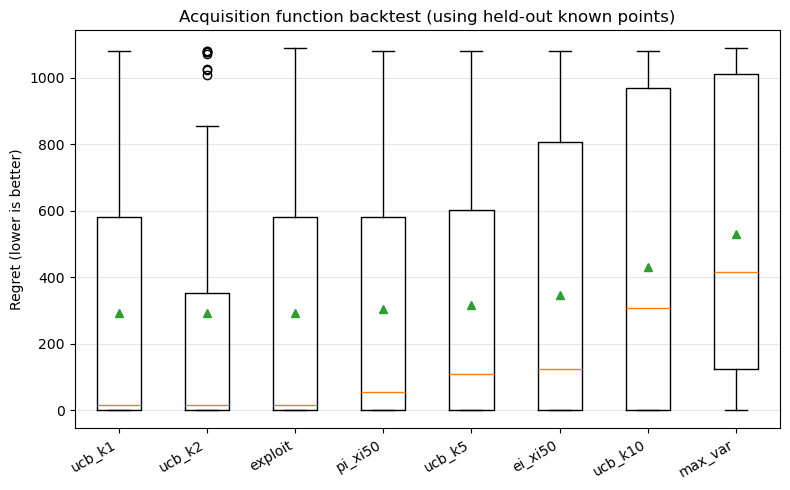

In [9]:
backtest_configs = [
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ucb_k10",  "acquisition": "ucb", "kappa": 10.0},
    {"name": "ei_xi50",  "acquisition": "ei",  "xi": 50.0},
    {"name": "pi_xi50",  "acquisition": "pi",  "xi": 50.0},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

plot_acquisition_backtest(backtest_results)
plt.show()

## Compare kappa values

Two views. First `compare_kappa_proposals` over all four axes, shown mainly to demonstrate the problem: every `kappa` parks the two flat axes on domain edges, and those coordinates are optimiser artifacts rather than predictions. Then the restricted view, which is what the choice is made from.

`KAPPA = 1.0` is kept, but the sweep does not really discriminate here. Every value from 0.5 to 2.0 returns the same `x2` = `x3` = 1 corner, because the response is monotone toward it inside the cube. So there is no mode switch to avoid and no exploration/exploitation trade to tune — the constrained optimum is on the boundary and every reasonable `kappa` finds it.

An earlier version of this cell built an elaborate argument about staying within one length-scale of the data, rejecting `kappa=5` because it put `x2` exactly on the padded upper bound of 1.6700. That whole framing belonged to the padded-bounds search and is gone: 1.6700 is not a reachable coordinate any more.

[fitting: unrestricted kappa sweep] 2 warnings held back, 2 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
=== unrestricted over all 4 axes (shown to demonstrate the problem) ===
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
     0.5 | [0.   ,0.773,1.   ,1.   ] |  1606.9873 |  1527.9606 |  158.0534 |          0.2914
       1 | [0.   ,0.171,1.   ,1.   ] |  1687.2239 |  1519.9734 |  167.2505 |          0.7321
       2 |            [0.,0.,1.,1.] |  1858.5677 |  1515.6174 |  171.4752 |          0.8922
       5 |            [1.,0.,1.,1.] |  2378.7877 |  1499.9072 |  175.7761 |          1.1609
      10 |            [1.,0.,1.,1.] |  3257.6683 |  1499.9072 |  175.7761 |          1.1609

how many coordinates sit on a bound in each

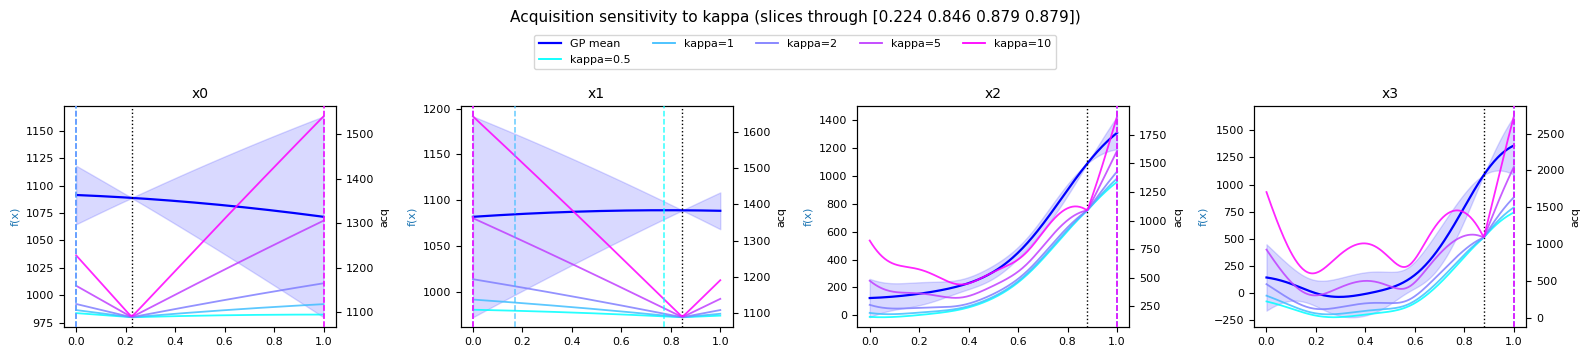


=== restricted to x3 (what the choice is made from) ===
x3 length-scale: 0.4257 normalised = 0.4257 raw; last observation at x3=0.9576

 kappa |        x3 |     step | length-scales out |  pred mean |  pred std | on bound
     0 |    1.0000 |  +0.1215 |              0.10 |    +1360.2 |     137.3 | True
     1 |    1.0000 |  +0.1215 |              0.10 |    +1360.2 |     137.3 | True
     2 |    1.0000 |  +0.1215 |              0.10 |    +1360.2 |     137.3 | True
     5 |    1.0000 |  +0.1215 |              0.10 |    +1360.2 |     137.3 | True

GP mean peaks along x3 at 1.0000 (mean +1360.2), 0.10 length-scales past
the last observation (x3=0.9576) -- a short extrapolation, not a far one.

the caution: over the three highest-x3 observations, y DECREASES --
  x3=0.8785 -> y=  1088.9   (other axes [0.224 0.846 0.879])
  x3=0.9337 -> y=   355.8   (other axes [0.439 0.774 0.378])
  x3=0.9576 -> y=   233.2   (other axes [0.463 0.63  0.108])
while the GP predicts +1360.2 at x3=1.0. That loo

In [10]:
with fitting("unrestricted kappa sweep"):
    kappa_rows = compare_kappa_proposals(X, y, bounds,
                                         kappa_values=[0.5, 1.0, 2.0, 5.0, 10.0],
                                         maximize=True, n_restarts=30, random_state=0)

print("=== unrestricted over all 4 axes (shown to demonstrate the problem) ===")
print_kappa_comparison(kappa_rows)
print("\nhow many coordinates sit on a bound in each unrestricted proposal?")
for row in kappa_rows:
    n_edge = sum(np.isclose(row["x_next"][d], bounds[d, 0])
                 or np.isclose(row["x_next"][d], bounds[d, 1]) for d in range(D))
    print(f"  kappa={row['kappa']:<5g} on_bound={n_edge}/{D}"
          f"  in_hull={bool(hull.find_simplex(row['x_next']) >= 0)}")

plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()

print(f"\n=== restricted to x{DIM} (what the choice is made from) ===")
scan_grid = np.tile(incumbent, (4000, 1))
scan_grid[:, DIM] = np.linspace(bounds[DIM, 0], bounds[DIM, 1], 4000)
scan_norm = normalize(scan_grid, bounds)
scan_mean, scan_std = gp_check.predict(scan_norm, return_std=True)

# Express each candidate's step in LENGTH-SCALES past the last observation --
# that, not the GP's apparent peak, is the criterion (see the markdown above).
ls_raw = ls_after[DIM] * (bounds[DIM, 1] - bounds[DIM, 0])
last_obs = X[:, DIM].max()
print(f"x{DIM} length-scale: {ls_after[DIM]:.4f} normalised = {ls_raw:.4f} raw;"
      f" last observation at x{DIM}={last_obs:.4f}\n")
print(f"{'kappa':>6} | {'x' + str(DIM):>9} | {'step':>8} | {'length-scales out':>17}"
      f" | {'pred mean':>10} | {'pred std':>9} | on bound")
for k in [0.0, 1.0, 2.0, 5.0]:
    j = int(np.argmax(ucb_acquisition(scan_norm, gp_check, kappa=k, maximize=True)))
    xv = scan_grid[j, DIM]
    on_b = np.isclose(xv, bounds[DIM, 1]) or np.isclose(xv, bounds[DIM, 0])
    print(f"{k:6g} | {xv:9.4f} | {xv - incumbent[DIM]:+8.4f} | {(xv - last_obs) / ls_raw:17.2f}"
          f" | {scan_mean[j]:+10.1f} | {scan_std[j]:9.1f} | {on_b}")

peak = scan_grid[int(np.argmax(scan_mean)), DIM]
print(f"\nGP mean peaks along x{DIM} at {peak:.4f} (mean {scan_mean.max():+.1f}),"
      f" {(peak - last_obs) / ls_raw:.2f} length-scales past")
print(f"the last observation (x{DIM}={last_obs:.4f}) -- a short extrapolation, not a far one.")

# This block used to conclude "a kernel artifact, not a measured maximum" and
# printed the three highest-x3 points as evidence y was "still rising". Both
# were artefacts of the padded-bounds era: back then the peak sat far outside
# the data, whereas now it is 0.1 length-scales out -- and those three y values
# FALL, so the old label was simply the wrong way round. Reported straight,
# because this is the real caution on the proposal.
hi = np.argsort(X[:, DIM])[-3:]
print(f"\nthe caution: over the three highest-x{DIM} observations, y DECREASES --")
for i in hi:
    print(f"  x{DIM}={X[i, DIM]:.4f} -> y={y[i]:8.1f}"
          f"   (other axes {np.round(np.delete(X[i], DIM), 3)})")
print(f"while the GP predicts {scan_mean[-1]:+.1f} at x{DIM}=1.0. That looks alarming until")
print("you read the other-axes column: x2 falls 0.879 -> 0.378 -> 0.108 down those")
print(f"same three rows, and x2 is the second most informative axis. So the drop is")
print(f"x2 going away, not x{DIM} turning over -- the two axes are confounded across")
print(f"these points and x{DIM} is not contradicted. Spearman(x{DIM}, y) ="
      f" {spearmanr(X[:, DIM], y)[0]:+.3f} overall.")
print("Worth re-running each week: if a future high-x%d point holds x2 high and y" % DIM)
print("still falls, that WOULD be a real contradiction.")

# How weak is the underlying trend, model-free?
if (y > 0).all():
    coef = np.polyfit(X[:, DIM], np.log(y), 1)
    r2 = pearsonr(X[:, DIM], np.log(y))[0] ** 2
    print(f"\nmodel-free check: log y ~ {coef[0]:.3f}*x{DIM} + {coef[1]:.3f},"
          f" r^2 = {r2:.3f} (weak)")
    # Evaluated at the DOMAIN maximum. This used to be hardcoded at x2=1.3656 --
    # week 3's out-of-domain coordinate, compared against a GP mean of ~7344
    # that was itself fitted to the excluded points. Both numbers were from the
    # world before the domain fix.
    print(f"  its extrapolation at the domain max x{DIM}=1.0: y ~"
          f" {np.exp(np.polyval(coef, bounds[DIM, 1])):.0f},"
          f" vs the GP's {scan_mean[-1]:+.0f}")
    print("  A weak log-linear trend is not a rival prediction -- just a reminder")
    print("  that extrapolating past the sampled region rests on thin evidence.")

KAPPA = 1.0
print(f"\nusing kappa = {KAPPA} (dimensionless -- no y-scaling needed),"
      f" searching {SEARCH_DIMS} and holding {tuple(FLAT)} at the incumbent")

## Propose the next point

UCB scanned over all informative axes at once, with the flat axes held at the incumbent because the acquisition is flat along them and would otherwise park them at an arbitrary edge.

Two checks read differently now that bounds are the true domain.

- **A coordinate on a bound is not a red flag.** With padding it meant the box was choosing the point; `[0,1]` is the real domain, so a coordinate at 1.0 means the constrained optimum sits on the boundary.
- **A convex-hull `False` is expected and benign**, but not for the reason the old version gave. It is not that "the ridge continues past the sampled region" — that argument belonged to the out-of-domain search. It is simply that a domain corner lies outside the hull of 20 interior points, as it must. What matters is that the step is small: +0.121 on `x2` and +0.122 on `x3` from the incumbent, which is 0.121 and 0.042 past the furthest observed value on each axis.

In [11]:
# Scan every informative axis jointly, holding the flat ones at the incumbent.
n_grid = 120
axes = [np.linspace(bounds[d, 0], bounds[d, 1], n_grid) if d in SEARCH_DIMS
        else np.array([incumbent[d]]) for d in range(D)]
grid = np.array(list(product(*axes)))
grid_norm = normalize(grid, bounds)

gp = gp_check
mu_g, sd_g = gp.predict(grid_norm, return_std=True)
j = int(np.argmax(ucb_acquisition(grid_norm, gp, kappa=KAPPA, maximize=True)))
x_next = grid[j].copy()
mu, sigma = mu_g[j], sd_g[j]

print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print(f"searched {SEARCH_DIMS} over a {n_grid}^{len(SEARCH_DIMS)} grid;"
      f" held {tuple(FLAT)} at the incumbent")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu:.6g}, predicted std: {sigma:.6g}")
print(f"current best in-domain y: {y.max():.6g}"
      f"  -> predicted improvement: {mu - y.max():+.6g}")
for d in SEARCH_DIMS:
    print(f"  step along x{d} from the incumbent: {x_next[d] - incumbent[d]:+.4f}"
          f"   (observed max {X[:, d].max():.4f}, domain max {bounds[d, 1]:.1f})")
print(f"flat axes unchanged from the incumbent:"
      f" {np.allclose(x_next[list(FLAT)], incumbent[list(FLAT)]) if FLAT else 'n/a'}")

# What the one-axis version would have given, so the gain is visible.
for dims in [(DIM,)] + ([SEARCH_DIMS] if SEARCH_DIMS != (DIM,) else []):
    ax = [np.linspace(bounds[d, 0], bounds[d, 1], n_grid) if d in dims
          else np.array([incumbent[d]]) for d in range(D)]
    g2 = np.array(list(product(*ax))); gn2 = normalize(g2, bounds)
    m2, _ = gp.predict(gn2, return_std=True)
    j2 = int(np.argmax(ucb_acquisition(gn2, gp, kappa=KAPPA, maximize=True)))
    print(f"  searching {str(dims):<8} -> pred mean {m2[j2]:8.1f}")

# --- Checks --------------------------------------------------------------
# NOTE: bounds are the TRUE DOMAIN [0,1], not padded. A coordinate on a bound
# therefore means the constrained optimum is on the boundary -- legitimate, not
# a pad_fraction artifact. The old warning here said the opposite and has been
# removed; what is worth flagging instead is a LOWER-bound contact, which would
# mean the acquisition wants to leave the feasible region downward.
on_upper = [d for d in range(D) if np.isclose(x_next[d], bounds[d, 1])]
on_lower = [d for d in range(D) if np.isclose(x_next[d], bounds[d, 0])]
print("\non the domain's UPPER edge:", on_upper or "none",
      "  (legitimate: the optimum can sit on the boundary)")
print("on the domain's LOWER edge:", on_lower or "none")
if on_lower:
    print("*** A coordinate is on the 0.0 floor -- the acquisition wants to leave")
    print("    the feasible region. Treat that proposal with suspicion. ***")

assert np.all(x_next >= 0.0) and np.all(x_next <= 1.0), \
    "proposal is outside the [0,1] domain -- that is the bug this week fixed"

outside_obs = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("dimensions beyond the observed range (but inside the domain):",
      outside_obs or "none")
print(f"inside the convex hull of the observations: "
      f"{bool(hull.find_simplex(x_next) >= 0)}"
      "   (False expected: a domain corner lies outside the hull of interior points)")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.4f}")
print("nearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+10.2f}  X={np.round(X[i], 3)}")

--- Next point to evaluate (bounds shape (4, 2)) ---
searched (2, 3) over a 120^2 grid; held (0, 1) at the incumbent
x_next: [0.224189 0.84648  1.       1.      ]
2.26**2 * Matern(length_scale=[10, 9.32, 0.761, 0.426], nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: 1527.06, predicted std: 157.29
current best in-domain y: 1088.86  -> predicted improvement: +438.204
  step along x2 from the incumbent: +0.1205   (observed max 0.8795, domain max 1.0)
  step along x3 from the incumbent: +0.1215   (observed max 0.9576, domain max 1.0)
flat axes unchanged from the incumbent: True
  searching (3,)     -> pred mean   1360.2
  searching (2, 3)   -> pred mean   1527.1

on the domain's UPPER edge: [2, 3]   (legitimate: the optimum can sit on the boundary)
on the domain's LOWER edge: none
dimensions beyond the observed range (but inside the domain): [2, 3]
inside the convex hull of the observations: False   (False expected: a domain corner lies outside the hull of interior points)

dis

## Visualise the GP and acquisition function via 1D slices

Each panel holds the other three dimensions at the best observed point and sweeps one. Dotted line is the fixed centre, dashed red is `x_next`, green is UCB.

What to expect: the **`x2` and `x3` panels** both rise toward the right-hand edge, with `x_next` at the domain maximum on each. The **`x0` and `x1` panels are nearly flat** by comparison — a mean range of about 20 and 7 against x2's 1185 and x3's 1397. That flatness is why those two coordinates are held at the incumbent rather than optimised.

A partial view — the GP along each axis near the best point, not interactions.

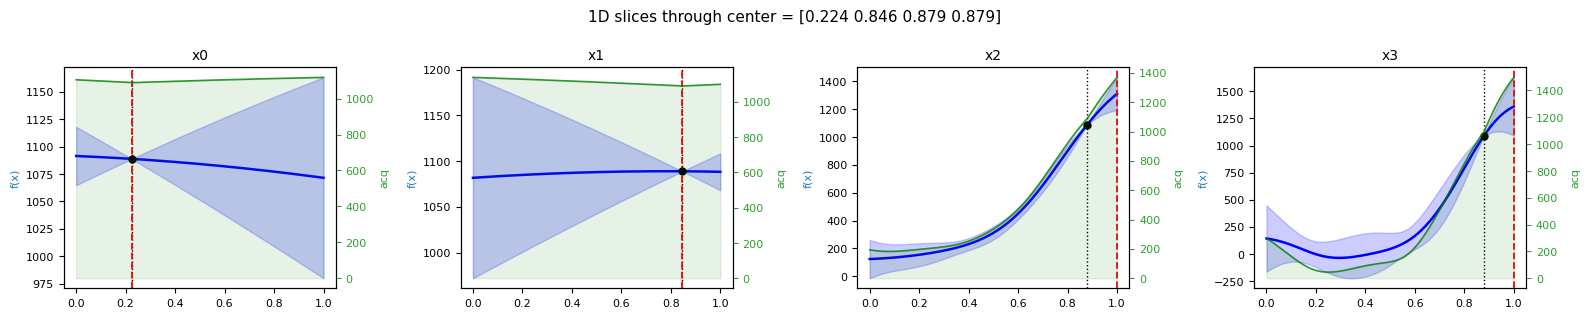

In [12]:
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate: leave-one-out calibration

Refitting once per observation, holding it out and predicting it from the rest. At D=4 this is the main way to judge the surrogate.

This runs on the modelling set, so the three out-of-domain points are absent by construction — what it measures is the surrogate actually in use rather than the one they distorted. Read the error bars rather than the correlation: 18 of 20 points fall inside their own 95% interval.

[fitting: leave-one-out calibration] 50 warnings held back, 3 distinct:
    20 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    20 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    10 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0


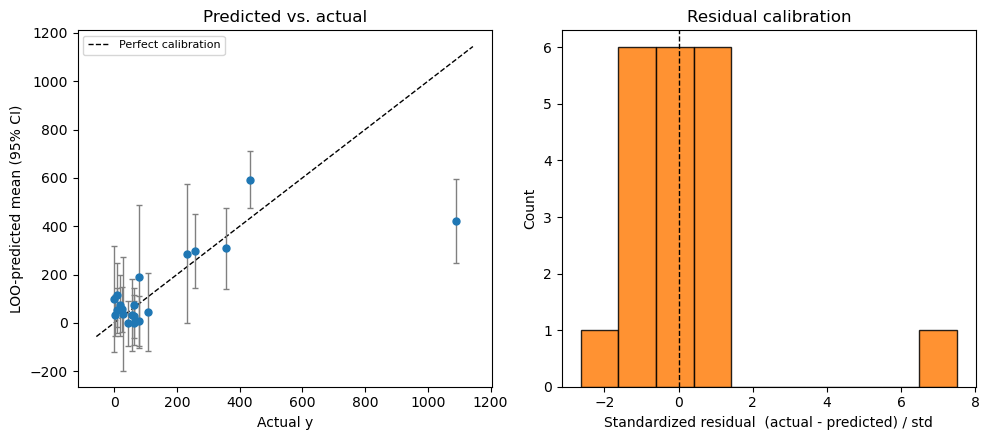

points inside their own 95% LOO interval: 18/20
worst-predicted point: index 15 (initial batch) -> true 1089, predicted 420.7 (std 89.04)


In [13]:
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(X, y, bounds,
                                          gp_kwargs={"n_restarts_optimizer": 20})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")

# The modelling set is the initial batch alone this week (all three collected
# points are out of domain and excluded), so the old `worst == n_initial` test
# had no row to point at. Report which point it is instead.
worst = int(np.argmax(np.abs(y - pred_mean)))
src = "initial batch" if worst < n_initial else f"collected #{worst - n_initial + 1}"
print(f"worst-predicted point: index {worst} ({src}) -> true {y[worst]:.4g},"
      f" predicted {pred_mean[worst]:.4g} (std {pred_std[worst]:.4g})")

## Iteration diagnostics

Replaying the ordered observations to reconstruct the acquisition value, GP hyperparameters and domain-wide uncertainty at each past proposal.

There is nothing to replay this week: all three collected points are excluded from the fit, so the modelling set is the initial batch and no iteration follows it. The section becomes meaningful once an in-domain evaluation lands.

Row order has to be true chronological order. `plot_bo_diagnostics` is skipped — it hard-codes a 2D scatter panel — and the trend plots are gated on having a few completed iterations.

In [14]:
# The replay only sees the MODELLING set, which is the initial batch alone this
# week -- all three collected points are out of domain and excluded. So there is
# nothing to replay, and n_replayed is the honest count (not len(new_y)).
n_replayed = len(y) - n_initial
history = None

if n_replayed == 0:
    print(f"Nothing to replay: {len(new_y)} observation(s) collected, all"
          f" {len(EXCLUDE_FROM_FIT)} excluded from the fit as out of domain.")
    print(f"Best in-domain y so far: {y.max():.4f}")
    print("This section becomes meaningful once an in-domain evaluation lands.")
else:
    with fitting("iteration-diagnostics replay"):
        history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                                acquisition="ucb", kappa=KAPPA,
                                                maximize=True)
    print("Best y so far:", np.nanmax(history["y"]))
    print(f"completed iterations in the modelling set: {n_replayed}"
          f"  ({len(new_y)} collected, {len(new_y) - n_replayed} excluded)")

    if n_replayed >= 3:
        for plot_fn in (plot_convergence, plot_acquisition_decay,
                        plot_uncertainty_shrinkage, plot_step_distance):
            plot_fn(history)
            plt.show()
    else:
        print(f"\nOnly {n_replayed} replayed iteration(s) -- need at least 3 before")
        print("the trend plots say anything. Skipping them.")

Nothing to replay: 3 observation(s) collected, all 3 excluded from the fit as out of domain.
Best in-domain y so far: 1088.8596
This section becomes meaningful once an in-domain evaluation lands.


## Raw diagnostic fields

In [15]:
if history is not None:
    print("y:", np.round(history["y"], 3))
    print("\niteration:", history["iteration"])
    print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
    print("\npred_mean at proposal time:", history["pred_mean"])
    print("\nlength_scale:", history["length_scale"])
    print("\ndomain_mean_std:", history["domain_mean_std"])

In [16]:
# My proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X. THIS notebook hit that failure at week 5: a 6-dp copy of the
# week-4 proposal (1.670022) rounded 4.8e-7 outside x2's own bound and tripped
# validate_bounds_consistency. Bounds are the unit cube now, so a coordinate at
# exactly 1.0 is the case to watch.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.224189-0.846480-1.000000-1.000000

full precision (use for next week's new_X):
0.22418902330288348-0.8464804904862864-1.0-1.0


In [17]:
# I record this week's proposal in the weekly store. This rewrites inputs.csv
# rather than appending, so re-running the notebook cannot double-record. I
# submit the 6-dp string printed above -- it is the same value written here.
save_proposal(5, new_X, x_next)


wrote weekly_data/function_5/inputs.csv: 4 row(s) (3 resulted + 1 proposal)
  proposal row: 0.224189-0.846480-1.000000-1.000000


'weekly_data/function_5/inputs.csv'